# Лаб №1
## Вариационные ряды и выборочная функция распределения

##  задание

Для непрерывной и дискретной выборок построить вариационные ряды, найти выборочные
функции распределения и построить их графики.

##  данные

Непрерывная выборка объёма `n = 26`:

```text
10.20, 9.23, 8.77, 10.40, 9.44, 9.09, 6.30, 9.42, 6.12, 9.69, 8.59, 8.68, 7.97, 8.64, 6.45, 5.29, 5.00, 8.42, 8.84, 8.26, 6.66, 6.96, 6.51, 6.72, 6.00, 5.36
```

Дискретная выборка объёма `n = 30`:

```text
2, 3, 2, 1, 2, 2, 4, 0, 2, 4, 4, 0, 1, 5, 1, 1, 3, 2, 2, 1, 4, 2, 2, 0, 1, 2, 4, 2, 0, 2
```



- **Дискретный вариационный ряд**: упорядоченные различные значения выборки $x_{(1)} < x_{(2)} < \dots < x_{(N)}$ и их частоты $n_i$.
- **Относительная частота**: $\omega_i = \frac{n_i}{n}$.
- **Интервальный вариационный ряд**: разбиение диапазона значений на интервалы одинаковой длины $\Delta$.
- **Эмпирическая функция распределения**:

$$
F_n(x) = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}\{x_i \le x\}.
$$

Она является ступенчатой неубывающей функцией, а величина скачка в точке варианта равна его относительной частоте.


In [58]:
import math
import numpy as np
import matplotlib.pyplot as plt




discrete = [2, 3, 2, 1, 2, 2, 4, 0, 2, 4, 4, 0, 1, 5, 1, 1, 3, 2, 2, 1, 4, 2, 2, 0, 1, 2, 4, 2, 0, 2]
continuous = [10.2, 9.23, 8.77, 10.4, 9.44, 9.09, 6.30, 9.42, 6.12, 9.69, 8.59, 8.68, 7.97, 8.64, 6.45, 5.29, 5.00, 8.42, 8.84, 8.26, 6.66, 6.96, 6.51, 6.72, 6.00, 5.36]


In [59]:
def discrete_series(sample):
    values, counts = np.unique(np.asarray(sample), return_counts=True)
    rel = counts / counts.sum()
    cum = np.cumsum(rel)
    return values, counts, rel, cum

def interval_series(sample, bins=None):
    arr = np.asarray(sample, dtype=float)
    if bins is None:
        bins = max(1, int(round(math.sqrt(arr.size))))
    edges = np.linspace(arr.min(), arr.max(), bins + 1)
    counts, _ = np.histogram(arr, bins=edges)
    rel = counts / counts.sum()
    cum = np.cumsum(rel)
    mids = (edges[:-1] + edges[1:]) / 2
    return edges, mids, counts, rel, cum

# Данные выборки

# Расчет рядов
values, counts, rel, cum = discrete_series(discrete)
edges, mids, icounts, irel, icum = interval_series(continuous)

# --- ВЫВОД ДИСКРЕТНОГО РЯДА ---
print("="*50)
print("ДИСКРЕТНЫЙ ВАРИАЦИОННЫЙ РЯД")
print("="*50)
print(f"{'x_i':>5} | {'n_i':>5} | {'w_i (Частость)':>14} | {'F_n(x) (Накопл.)':>16}")
print("-" * 50)
for v, c, r, k in zip(values, counts, rel, cum):
    print(f"{v:>5} | {c:>5} | {r:>14.4f} | {k:>16.4f}")
print("="*50)
print(f"Итого: N = {counts.sum()}\n\n")

# --- ВЫВОД ИНТЕРВАЛЬНОГО РЯДА ---
print("="*65)
print("ИНТЕРВАЛЬНЫЙ ВАРИАЦИОННЫЙ РЯД")
print("="*65)
print(f"{'Интервал (x_i; x_i+1]':>22} | {'n_i':>5} | {'w_i (Частость)':>14} | {'F_n(x)':>10}")
print("-" * 65)
for i in range(len(icounts)):
    interval_str = f"[{edges[i]:.2f}; {edges[i+1]:.2f})"
    print(f"{interval_str:>22} | {icounts[i]:>5} | {irel[i]:>14.4f} | {icum[i]:>10.4f}")
print("="*65)
print(f"Итого: N = {icounts.sum()}")

ДИСКРЕТНЫЙ ВАРИАЦИОННЫЙ РЯД
  x_i |   n_i | w_i (Частость) | F_n(x) (Накопл.)
--------------------------------------------------
    0 |     4 |         0.1333 |           0.1333
    1 |     6 |         0.2000 |           0.3333
    2 |    12 |         0.4000 |           0.7333
    3 |     2 |         0.0667 |           0.8000
    4 |     5 |         0.1667 |           0.9667
    5 |     1 |         0.0333 |           1.0000
Итого: N = 30


ИНТЕРВАЛЬНЫЙ ВАРИАЦИОННЫЙ РЯД
 Интервал (x_i; x_i+1] |   n_i | w_i (Частость) |     F_n(x)
-----------------------------------------------------------------
          [5.00; 6.08) |     4 |         0.1538 |     0.1538
          [6.08; 7.16) |     7 |         0.2692 |     0.4231
          [7.16; 8.24) |     1 |         0.0385 |     0.4615
          [8.24; 9.32) |     9 |         0.3462 |     0.8077
         [9.32; 10.40) |     5 |         0.1923 |     1.0000
Итого: N = 26


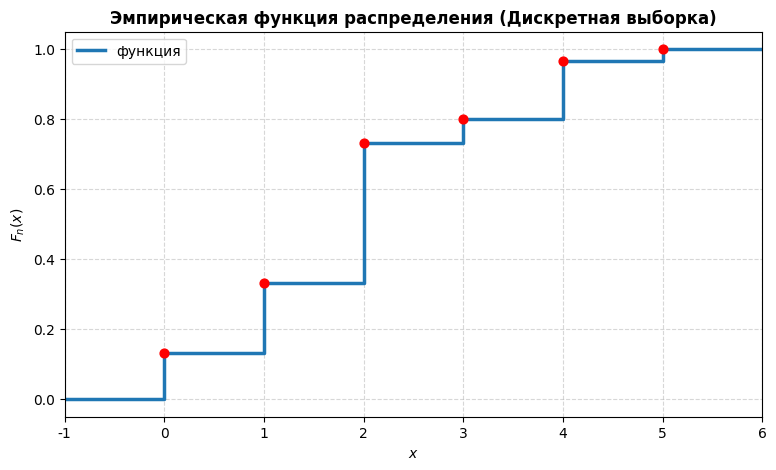

In [60]:
plt.figure(figsize=(9, 5))

# Формируем точки для бесконечных хвостов функции (до x_min функция равна 0, после x_max равна 1)
x_disc = np.concatenate(([values[0] - 1], values, [values[-1] + 1]))
y_disc = np.concatenate(([0], cum, [1]))

# Строим ступенчатый график
plt.step(x_disc, y_disc, where="post", color="#1f77b4", linewidth=2.5, label="функция")

# Наносим точки разрывов
plt.scatter(values, cum, color="red", zorder=3, s=40)

plt.title("Эмпирическая функция распределения (Дискретная выборка)", fontsize=12, fontweight='bold')
plt.xlabel("$x$", fontsize=10)
plt.ylabel("$F_n(x)$", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(x_disc[0], x_disc[-1])
plt.ylim(-0.05, 1.05)
plt.legend(loc="upper left")

plt.show() # Эта команда выведет график прямо под ячейкой

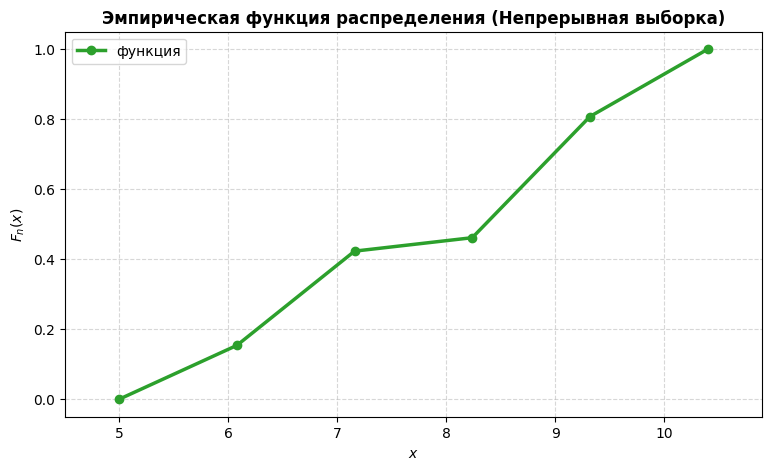

In [61]:
plt.figure(figsize=(9, 5))

# Для интервального ряда график начинается с 0 на левой границе первого интервала
x_cont = edges
y_cont = np.concatenate(([0], icum))

# Строим кумулятивную ломаную линию
plt.plot(x_cont, y_cont, marker="o", color="#2ca02c", linewidth=2.5, label="функция")

plt.title("Эмпирическая функция распределения (Непрерывная выборка)", fontsize=12, fontweight='bold')
plt.xlabel("$x$", fontsize=10)
plt.ylabel("$F_n(x)$", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(edges[0] - 0.5, edges[-1] + 0.5)
plt.ylim(-0.05, 1.05)
plt.legend(loc="upper left")

plt.show() # Вывод второго графика в блокноте